<a href="https://colab.research.google.com/github/mrabinayaa/DAAexps/blob/main/exp7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


N = 4
Solutions  : 2
Backtracks : 60

All Solutions:

Solution 1: [1, 3, 0, 2]
 +---+---+---+---+
 | . | Q | . | . |
 +---+---+---+---+
 | . | . | . | Q |
 +---+---+---+---+
 | Q | . | . | . |
 +---+---+---+---+
 | . | . | Q | . |
 +---+---+---+---+


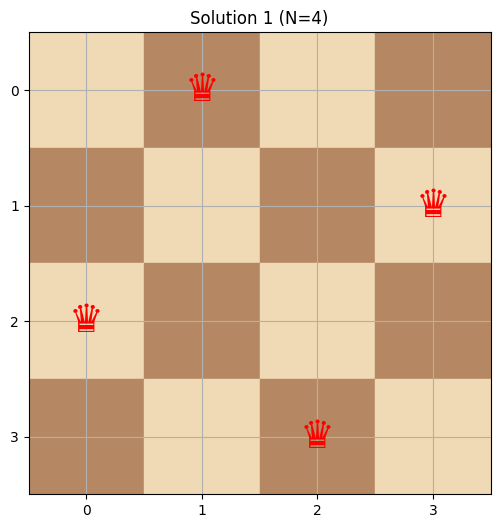

Solution 2: [2, 0, 3, 1]
 +---+---+---+---+
 | . | . | Q | . |
 +---+---+---+---+
 | Q | . | . | . |
 +---+---+---+---+
 | . | . | . | Q |
 +---+---+---+---+
 | . | Q | . | . |
 +---+---+---+---+


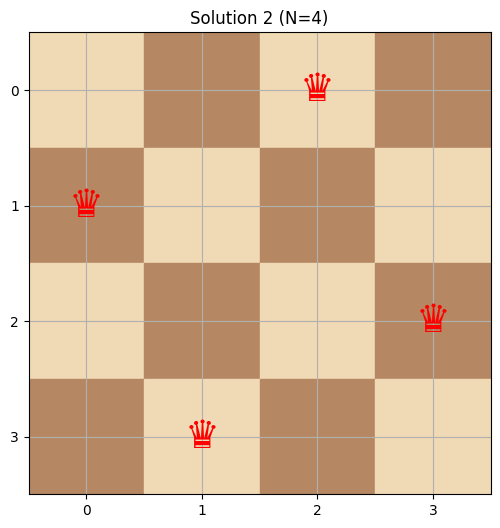


N = 6
Solutions  : 4
Backtracks : 894

N = 8
Solutions  : 92
Backtracks : 15720


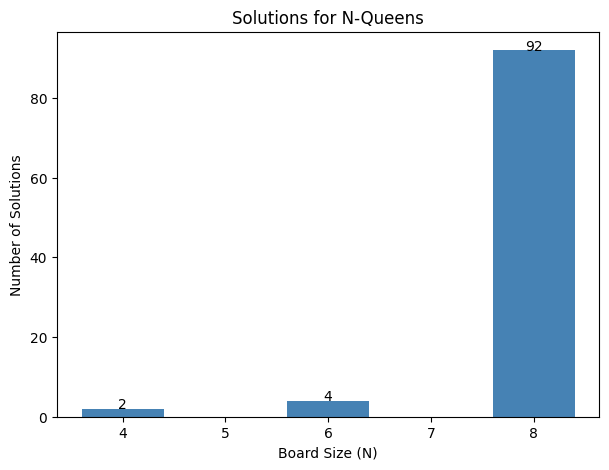

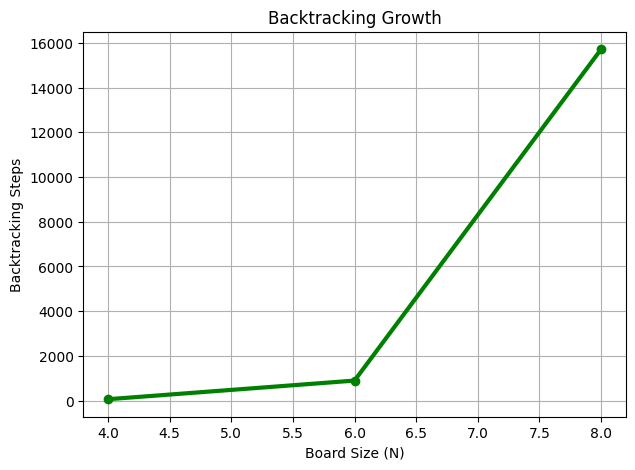

In [4]:
import matplotlib.pyplot as plt
import numpy as np


# ----------------------------------------------------
# Check whether a queen can be placed safely
# ----------------------------------------------------
def is_safe(board, row, col):
    for prev_row in range(row):
        placed = board[prev_row]

        # Same column
        if placed == col:
            return False

        # Diagonal
        if abs(prev_row - row) == abs(placed - col):
            return False

    return True


# ----------------------------------------------------
# Solve N Queens using Backtracking
# ----------------------------------------------------
def solve_n_queens(n):
    board = [-1] * n
    solutions = []
    backtrack_count = [0]

    def backtrack(row):
        if row == n:
            solutions.append(board[:])
            return

        for col in range(n):

            if is_safe(board, row, col):

                board[row] = col

                backtrack(row + 1)

                board[row] = -1

            backtrack_count[0] += 1

    backtrack(0)

    return solutions, backtrack_count[0]


# ----------------------------------------------------
# Console Board
# ----------------------------------------------------
def display_board(solution, n):

    print(" +" + "---+" * n)

    for row in range(n):

        print(" |", end="")

        for col in range(n):

            if solution[row] == col:
                print(" Q |", end="")
            else:
                print(" . |", end="")

        print()
        print(" +" + "---+" * n)


# ----------------------------------------------------
# Graphical Chess Board
# ----------------------------------------------------
def plot_board(solution, n, title):

    board = np.zeros((n, n))

    fig, ax = plt.subplots(figsize=(6, 6))

    ax.imshow(board, cmap="binary")

    # Chessboard colors
    for i in range(n):
        for j in range(n):
            color = "#F0D9B5" if (i + j) % 2 == 0 else "#B58863"
            ax.add_patch(
                plt.Rectangle(
                    (j - 0.5, i - 0.5),
                    1,
                    1,
                    color=color
                )
            )

    # Draw Queens
    for row in range(n):
        col = solution[row]

        ax.text(
            col,
            row,
            "♛",
            fontsize=28,
            ha='center',
            va='center',
            color='red'
        )

    ax.set_xticks(range(n))
    ax.set_yticks(range(n))

    ax.set_title(title)
    plt.grid(True)
    plt.show()


# ----------------------------------------------------
# Bar Chart
# ----------------------------------------------------
def plot_solution_counts(ns, counts):

    plt.figure(figsize=(7, 5))

    plt.bar(ns, counts, color="steelblue")

    plt.xlabel("Board Size (N)")
    plt.ylabel("Number of Solutions")

    plt.title("Solutions for N-Queens")

    for i, v in enumerate(counts):
        plt.text(ns[i], v, str(v), ha="center")

    plt.show()


# ----------------------------------------------------
# Line Chart
# ----------------------------------------------------
def plot_backtracking(ns, backtracks):

    plt.figure(figsize=(7, 5))

    plt.plot(
        ns,
        backtracks,
        marker='o',
        linewidth=3,
        color="green"
    )

    plt.grid(True)

    plt.xlabel("Board Size (N)")
    plt.ylabel("Backtracking Steps")

    plt.title("Backtracking Growth")

    plt.show()


# ====================================================
# MAIN
# ====================================================

board_sizes = [4, 6, 8]

solution_counts = []
backtracking_counts = []

for n in board_sizes:

    solutions, backtracks = solve_n_queens(n)

    solution_counts.append(len(solutions))
    backtracking_counts.append(backtracks)

    print(f"\nN = {n}")
    print(f"Solutions  : {len(solutions)}")
    print(f"Backtracks : {backtracks}")

    if n == 4:

        print("\nAll Solutions:\n")

        for i, sol in enumerate(solutions, 1):

            print(f"Solution {i}: {sol}")

            display_board(sol, n)

            plot_board(sol, n, f"Solution {i} (N=4)")


# Graphs
plot_solution_counts(board_sizes, solution_counts)

plot_backtracking(board_sizes, backtracking_counts)